# Reading the Radar
### A hands-on guide to what weather radar sees — and misses

*Sebastián Torres · CIWRO, University of Oklahoma*  
*Clouds4Africa · July 2026*

---
**How to set up this notebook.** Wait until the top-right kernel indicator shows Python (Pyodide) and stops saying "Starting…" (the first load can take 30–60 seconds — this is normal). Go to the Run menu → Run All Cells. Scroll up/down and interact with the sliders. If anything looks broken on the very first try, run that one cell again (Shift+Enter).

**How to use this notebook.** Connect what you see on a radar display to the physics and system design behind it. Each widget has three question levels — *Basic*, *A little further*, *Going deeper* — so start where you're comfortable and push as far as you can; they're meant to stretch, not to be finished. Time per widget is short, so don't expect to clear every level here; the more advanced questions are designed to be picked up again after the workshop. The notebook is yours to keep and re-run afterward.

<sub>© 2026 Sebastián Torres · Licensed under CC BY-NC 4.0 · Contact: sebas@ou.edu · Materials: https://sebastiantorr.github.io/Clouds4Africa/tree/</sub>

In [ ]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Block 1: The beam in space
### Where does the echo actually come from?

The most intuitive place to start: a radar doesn't measure a point, it measures a beam — one that spreads, climbs, bends, and can be blocked. This block has four widgets. Run the setup cell once, then work through the widgets in order, since each builds on the last.

## Before we start
This block is about *where* the radar's beam goes, and *where that fails*. Four ideas are all you need first.

1. **What a radar does.** It transmits a short pulse, then listens for the echo. Distance comes from the delay — a later echo is farther away. Everything below assumes the radar aims a beam in some direction and gets an echo back from along it.

2. **What the products are.** Reflectivity (in dBZ) tells you roughly how much and how large the scatterers are; the radar also measures radial velocity, spectrum width, and the dual-polarization variables. Block 1 leans almost entirely on reflectivity — the others arrive in later blocks.

3. **How the beam is aimed.** The beam points at an elevation angle (the *tilt*) and an *azimuth*, and sweeps a full circle to build a PPI. *Range* is distance outward along the beam, divided into *gates*. Tilt, azimuth, and range are the three coordinates every widget here uses.

4. **The one idea to hold onto: the beam is a volume, not a ray.** It has width and depth, it climbs with range, it can bend, and terrain can clip it. The four widgets just make that concrete — so "no echo" never quite means "no weather."

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

C = 2.998e8                # speed of light, m/s
A_E = 6371.0               # Earth radius, km

def beamwidth(freq_ghz=2.8, dish_m=8.5):
    # half-power beamwidth (deg)
    return np.degrees(1.27 * (C/(freq_ghz*1e9)) / dish_m)

def beam_height(r_km, elev_deg):
    # standard 4/3-Earth beam-center height (km)
    Re = (4/3)*A_E; phi = np.radians(elev_deg)
    return np.sqrt(r_km**2 + Re**2 + 2*r_km*Re*np.sin(phi)) - Re

def eff_radius(dNdh):
    # effective Earth radius (km) from refractivity gradient dN/dh (N-units per km)
    denom = 1 + A_E*dNdh*1e-6
    if abs(denom) < 1e-4: denom = 1e-4 if denom >= 0 else -1e-4
    return A_E/denom

def beam_height_ap(r_km, elev_deg, dNdh):
    # beam height under any refraction gradient (handles ducting)
    return r_km*np.sin(np.radians(elev_deg)) + r_km**2/(2*eff_radius(dNdh))

def blockage_fraction(terrain_km, beam_km, radius_km):
    # (simplified) fraction of the beam disc hidden by terrain (Bech et al. 2003)
    y, a = terrain_km - beam_km, radius_km
    f = (y*np.sqrt(np.clip(a**2-y**2,0,None)) + a**2*np.arcsin(np.clip(y/a,-1,1)) + np.pi*a**2/2)/(np.pi*a**2)
    return np.clip(f, 0, 1)

print("Block 1 ready | beamwidth", round(beamwidth(),3), "deg | beam center @150 km", round(float(beam_height(150,0.5)),2), "km")

Block 1 ready | beamwidth 0.917 deg | beam center @150 km 2.63 km


## 1 — The beam spreads: beamwidth from the dish

The half-power beamwidth is roughly θ ≈ 1.27 λ/D — wavelength over dish size. It's fixed in *degrees*, but that means the beam's physical width **grows with range**, so two storms close together blur into one far away.

In [ ]:
def show_beamwidth(freq_ghz=3, dish_m=7):
    bw = beamwidth(freq_ghz, dish_m)
    print("wavelength           ", round(C/(freq_ghz*1e9)*100, 1), "cm")
    print("half-power beamwidth ", round(bw, 3), "deg")
    print("beam width at 100 km ", round(100*np.radians(bw), 2), "km")
    print("beam width at 200 km ", round(200*np.radians(bw), 2), "km")

interact(show_beamwidth,
         freq_ghz=FloatSlider(value=3, min=1, max=10, step=0.1, description="freq GHz"),
         dish_m=FloatSlider(value=7, min=1, max=10, step=0.5, description="dish size m"));

wavelength            10.0 cm
half-power beamwidth  1.039 deg
beam width at 100 km  1.81 km
beam width at 200 km  3.63 km


interactive(children=(FloatSlider(value=3.0, description='freq GHz', max=10.0, min=1.0), FloatSlider(value=7.0…

**Basic**

1. At NEXRAD defaults (f = 2.8 GHz, D = 8.5 m), what is the beamwidth? How wide is the beam at 100 km versus 200 km?
2. Shrink the dish to a small, X-band, gap-filler radar (f = 9.4 GHz, D = 1.5 m). Does the beam get wider or narrower?

**A little further**

1. Keep the dish fixed and switch toward C-band (~5.6 GHz). Does the beam narrow or widen — and why does a shorter wavelength sharpen resolution?
2. Find a dish size that gives NEXRAD's ~0.9° beamwidth *at* C-band. Bigger or smaller than 8.5 m?

**Going deeper**


1. Beamwidth scales as λ/D, but antenna gain scales as (D/λ)². Double the dish from 5 m to 10 m: confirm the beamwidth halves, then state the corresponding change in gain in dB and what it buys you.
2. At NEXRAD defaults, the widget shows a beam width of 1.6 km at 100 km and 3.2 km at 200 km. At roughly what range do two cells 2 km apart merge into a single echo? Confirm the rule (width = r·θ), then explain why a fixed-dish radar can never hold cross-range resolution constant with range — unlike along-range resolution, which the pulse keeps fixed.



## 2 — The beam climbs: height and refraction

Under standard refraction the beam follows a curved path, but the Earth curves away faster, so the beam **rises with range**. The shaded band is the beam's full width; the line is its center.

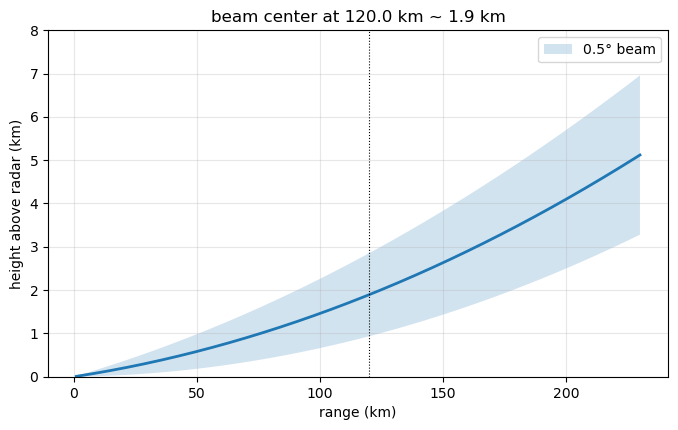

interactive(children=(FloatSlider(value=0.5, description='elevation°', max=10.0, min=0.5), FloatSlider(value=2…

In [ ]:
def plot_beam(elev=0.5, freq_ghz=2.8, dish_m=8.5, range_km = 120):
    bw = beamwidth(freq_ghz, dish_m); r = np.linspace(1, 230, 300)
    plt.figure(figsize=(8, 4.5))
    plt.fill_between(r, beam_height(r, elev-bw/2), beam_height(r, elev+bw/2), alpha=0.2, label=str(elev)+"° beam")
    plt.plot(r, beam_height(r, elev), lw=2)
    plt.axvline(range_km, color="k", ls=":", lw=0.8);
    plt.ylim(0, 8); plt.grid(alpha=0.3); plt.legend()
    plt.xlabel("range (km)"); plt.ylabel("height above radar (km)")
    plt.title("beam center at " + str(range_km) + " km ~ " + str(round(float(beam_height(range_km, elev)),1)) + " km")
    plt.show()

interact(plot_beam,
         elev=FloatSlider(value=0.5, min=0.5, max=10, step=0.1, description="elevation°"),
         freq_ghz=FloatSlider(value=2.8, min=1, max=10, step=0.1, description="freq GHz"),
         dish_m=FloatSlider(value=8.5, min=1, max=10, step=0.5, description="dish m"),
         range_km=FloatSlider(value=120, min=0, max=250, step=10, description="range km"));

**Basic**

1. At the 0.5° tilt, how high is the beam center at 120 km? At 200 km?
2. You care about shallow rain at 150 km. Is the lowest beam near the surface, or well above it?

**A little further**

1. Raise the tilt to 1.5°. How much higher is the beam at 150 km, and when would you accept that (think terrain)?
2. Read the top and bottom of the band at 150 km — the beam is ~2 km deep. Is that spread from the beamwidth, the refraction, or both?

**Going deeper**
1. At 0.5° the beam center is ~2.6 km at 150 km. Split that into the geometric rise (r·sinθ) and the Earth-curvature term (r²/2Rₑ): compute each. Find the range where the two terms are equal, and show it scales as 2·Rₑ·sinθ. Which term dominates near the radar, and which far out?
2. A melting layer / bright band sits near 3 km. Find the range at which the 0.5° beam center reaches 3 km — beyond it, low-tilt QPE is sampling ice aloft, not surface rain. Now find that same overshoot range if you're forced up to 1.5° (because 0.5° is blocked). How much coverage did the blockage cost you?
3. The beam isn't a line — its vertical depth is ≈ r·θ. Read the top and bottom edges of the shaded band at 150 km and state the height layer the measurement integrates over. Why can't a sharp inversion or a shallow cold pool inside that layer be resolved, no matter how good the radar is?

## 3 — The beam bends abnormally: anomalous propagation

So far we've used the **4/3-Earth model**: radar waves bend slightly downward as they travel, and we capture that by pretending the Earth's radius is *k* = 4/3 of its true value and letting the beam travel straight. That factor *k* is the **effective Earth radius factor** — and it isn't a constant of nature. It depends on the atmosphere.

What sets it is **refractivity** N — roughly, how much the air slows radio waves, driven by pressure, temperature, and humidity. N normally decreases with height, and it's the **vertical gradient** dN/dh (in N-units per km) that bends the beam. The effective radius follows

R_eff = aₑ / (1 + aₑ · (dN/dh) · 10⁻⁶),   and   k = R_eff / aₑ,

with aₑ = 6371 km. A **standard atmosphere** has dN/dh ≈ −39 N/km, which gives k = 4/3 — exactly the case we've been using. Slide dN/dh and watch k, the beam, and the regime respond:

- **Sub-refraction** (dN/dh toward 0 or positive): the beam bends *less*, climbs faster, and overshoots even more than standard.
- **Standard** (≈ −39 N/km): the familiar 4/3 curve.
- **Super-refraction** (more negative than around −39): the beam bends *down* harder and stays lower than standard.
- **Ducting** (around −157 N/km and below): the beam bends as sharply as the Earth curves — it gets trapped near the surface and can curve into the ground, painting **false echoes** (ground clutter where there is no weather).

The plot shows your beam (solid) against the standard 4/3 beam (dashed), with the terrain ridge and a marker if the beam strikes the ground; the title reports k and which regime you're in. A nighttime surface inversion is a common cause of strong super-refraction and ducting — and because such layers form and erode over hours, the artifacts they create come and go.

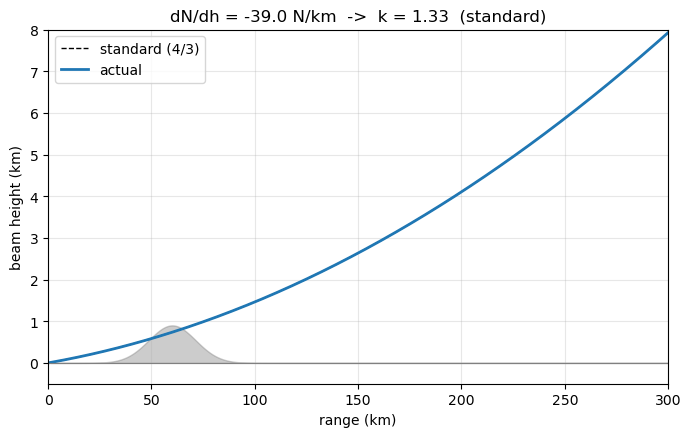

interactive(children=(FloatSlider(value=0.5, description='elevation°', max=3.0), FloatSlider(value=-39.0, desc…

In [ ]:
def plot_anaprop(elevation=0.5, dNdh=-39):
    r = np.linspace(1, 300, 500); h = beam_height_ap(r, elevation, dNdh)
    terrain = 0.9*np.exp(-((r-60)/16)**2); k = eff_radius(dNdh)/A_E
    regime = ("ducting" if dNdh <= -157 else "super-refraction" if dNdh < -44
              else "sub-refraction" if dNdh > -34 else "standard")
    plt.figure(figsize=(8, 4.6))
    plt.plot(r, beam_height_ap(r, elevation, -39), "k--", lw=1, label="standard (4/3)")
    plt.plot(r, h, color="tab:blue", lw=2, label="actual")
    plt.fill_between(r, 0, terrain, color="gray", alpha=0.4); plt.axhline(0, color="gray", lw=0.8)
    hit = r[h < 0]
    if len(hit):
        plt.plot(hit[0], 0, "rv", ms=11)
        plt.annotate("ground strike " + str(round(hit[0])) + " km", (hit[0], 0),
                     (max(hit[0]-95, 5), 1.2), color="red", fontsize=9)
    plt.xlim(0, 300); plt.ylim(-0.5, 8); plt.grid(alpha=0.3); plt.legend()
    plt.xlabel("range (km)"); plt.ylabel("beam height (km)")
    plt.title("dN/dh = " + str(dNdh) + " N/km  ->  k = " + ("inf" if k > 50 or k < 0 else str(round(k,2))) + "  (" + regime + ")")
    plt.show()

interact(plot_anaprop,
         elevation=FloatSlider(value=0.5, min=0, max=3, step=0.1, description="elevation°"),
         dNdh=FloatSlider(value=-39, min=-400, max=40, step=1, description="dN/dh"));

**Basic**

1. Set dN/dh to the standard value. What is k, and the beam height at 150 km? (Compare with widget 2.)
2. Drag to strong ducting (dN/dh = -300). Where does the beam strike the ground?

**A little further**

1. At what dN/dh does the beam run parallel to the Earth? Reason it from the effective radius going infinite, then confirm with the slider.
2. Find the dN/dh that bends the beam into the ridge it normally clears at an elevation of 0.9°. A nocturnal surface inversion does this — so why does AP clutter appear and vanish overnight?

**Going deeper**
1. Define modified refractivity M = N + 0.157·h (h in meters). Show that "ducting" becomes the clean criterion dM/dh < 0, and that this is identical to dN/dh < −157 N/km. Confirm the slider's ducting onset matches this threshold exactly.
2. For super-refraction the ground-strike range follows r ≈ −2·R_eff·sin θ. Predict that, at a fixed dN/dh, doubling the elevation should double the strike range. Test it on the widget at two elevations — and find the elevation/gradient combination where the small-angle approximation visibly starts to break down.
3. With the ridge at 60 km (0.9 km tall), find the dN/dh at which the 0.5° beam first grazes the ridge top it clears under standard refraction. Then explain why a single ducting night produces both AP ground clutter at long range and new terrain blockage on the same radar — and why both vanish after the morning mixing.

## 4 — The beam gets blocked: terrain

Near the radar, terrain hides part of the beam. The top panel shows the beam riding over a ridge; the bottom shows the blocked fraction at each gate (PBB) and the cumulative blockage along the ray (CBB).

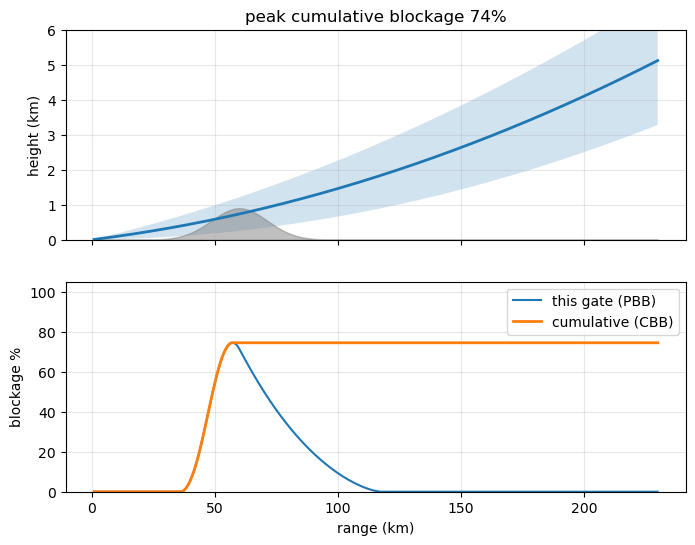

interactive(children=(FloatSlider(value=0.5, description='elevation°', max=4.0, min=0.5), FloatSlider(value=0.…

In [ ]:
def plot_blockage(elev=0.5, ridge_km=0.9, ridge_at=60):
    bw = beamwidth(); r = np.linspace(1, 230, 300)
    center = beam_height(r, elev); radius = r*np.radians(bw)/2
    terrain = ridge_km*np.exp(-((r-ridge_at)/16)**2); highest = np.maximum.accumulate(terrain)
    pbb = blockage_fraction(highest, center, radius); cbb = np.maximum.accumulate(pbb)
    fig, (top, bot) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    top.fill_between(r, beam_height(r, elev-bw/2), beam_height(r, elev+bw/2), alpha=0.2)
    top.plot(r, center, lw=2); top.fill_between(r, 0, terrain, color="gray", alpha=0.5)
    top.set_ylim(0, 6); top.set_ylabel("height (km)"); top.grid(alpha=0.3)
    top.set_title("peak cumulative blockage " + str(round(cbb.max()*100)) + "%")
    bot.plot(r, pbb*100, label="this gate (PBB)"); bot.plot(r, cbb*100, lw=2, label="cumulative (CBB)")
    bot.set_ylim(0, 105); bot.set_xlabel("range (km)"); bot.set_ylabel("blockage %"); bot.grid(alpha=0.3); bot.legend()
    plt.show()

interact(plot_blockage,
         elev=FloatSlider(value=0.5, min=0.5, max=4, step=0.1, description="elevation°"),
         ridge_km=FloatSlider(value=0.9, min=0, max=3, step=0.1, description="ridge km"),
         ridge_at=IntSlider(value=60, min=20, max=150, step=5, description="ridge @ km"));

**Basic**

1. With the default ridge, what is the peak cumulative blockage at 0.5°?
2. Raise the elevation. At roughly what tilt does the blockage clear?

**A little further**

1. Why does the cumulative blockage stay high *after* the ridge while the per-gate value drops back to zero? What does that mean for everything downrange of a blocked azimuth?
2. Move the ridge closer to the radar at the same height. Does it block more or less — and why (think about how high the beam is there)?

**Going deeper**

1. CBB is a fraction of power, so the remaining power is (1 − CBB) and the reflectivity bias is 10·log10(1 − CBB) dB. Using Z = 200·R^1.6, convert the default ridge's peak CBB into the percentage by which downrange rainfall is underestimated if you never correct it. Repeat for a 50% block — how much of the error is hidden in that "only half-blocked" gate?
2. Predict and then confirm that PBB ≈ 50% exactly when the terrain top reaches the beam center height. Read the 0.5° beam-center height at 60 km off Widget 2, set the ridge to that height, and check the PBB peak lands near 50%.
3. Networks typically correct gates up to ~70% cumulative blockage and discard everything beyond. For the default ridge, find the lowest elevation tilt that keeps CBB under 70% — then quantify, using Widget 2, exactly how much higher in the atmosphere you're now forced to sample by choosing that tilt. Is the trade worth it?

## 5 — Radar data (KNKX 11 March 2006, 22:25 UTC)
The four panels show the same storm at four elevation tilts — 0.50°, 1.40°, 3.00°, and
5.10° — of reflectivity. The radar hasn't moved and the weather is the same; only the tilt
has changed. Look for features that change with *height*: your job is to separate real
weather from what the beam and nearby obstacles are doing.

**Basic**

At the lowest tilt (0.50°), find the thin radial "spokes" of missing or weakened echo
running outward from the radar. Do they sit at the same azimuths as you step up through
1.40°, 3.00°, and 5.10° — and do they fill in or persist? Which idea from this block explains
gaps that are anchored to fixed directions yet disappear as the beam climbs?

**A little further**

Why does raising the tilt fill the spokes back in? Using the beam-height widget, reason about
where the beam goes at a blocked azimuth as the tilt increases relative to a near-radar
obstacle — and what that tells you about whether a spoke is blockage or real precipitation that
simply isn't there.

**Going deeper**

Tie blockage to its cost. The lowest tilt that clears the obstacles also samples higher in the
atmosphere — using the beam-height widget, estimate how much higher you're sampling at ~50 km
when you go from 0.50° to the tilt that fills the spokes, and what shallow low-level weather
you'd miss there. For a spoke that is weakened but not absent (a partial block), explain why
the reflectivity is biased low all the way downrange along that radial, and why a rainfall
estimate there would read too low even far beyond the obstacle.

![Image](https://raw.githubusercontent.com/sebastiantorr/Clouds4Africa/main/content/images/block1_image1.png)

## Block 1 takeaway
**A radar measurement is a beam of finite width that climbs with range, can bend abnormally, and can be clipped by terrain — so "no echo" is not the same as "no weather."**
